<a href="https://colab.research.google.com/github/ShivenSiwach/Sentement_analysis/blob/main/Sentement_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
# Load IMDb dataset
data = pd.read_csv("/content/IMDB Dataset.csv", engine='python', quotechar='"', on_bad_lines='skip')

print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (2417, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

data['clean_review'] = data['review'].apply(preprocess_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data['clean_review'])
y = data['sentiment'].map({'positive': 1, 'negative': 0})


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)


In [ ]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate_model("Naive Bayes", y_test, nb_pred)
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("SVM", y_test, svm_pred)



Naive Bayes Results
Accuracy: 0.8388429752066116
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       251
           1       0.81      0.86      0.84       233

    accuracy                           0.84       484
   macro avg       0.84      0.84      0.84       484
weighted avg       0.84      0.84      0.84       484


Logistic Regression Results
Accuracy: 0.8512396694214877
              precision    recall  f1-score   support

           0       0.89      0.81      0.85       251
           1       0.81      0.90      0.85       233

    accuracy                           0.85       484
   macro avg       0.85      0.85      0.85       484
weighted avg       0.86      0.85      0.85       484


SVM Results
Accuracy: 0.8450413223140496
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       251
           1       0.82      0.87      0.84       233

    accuracy                    

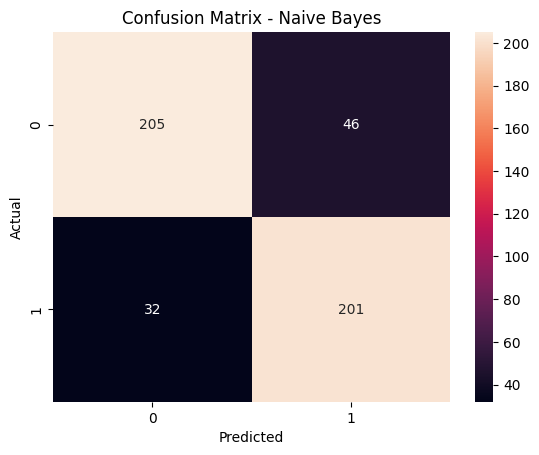

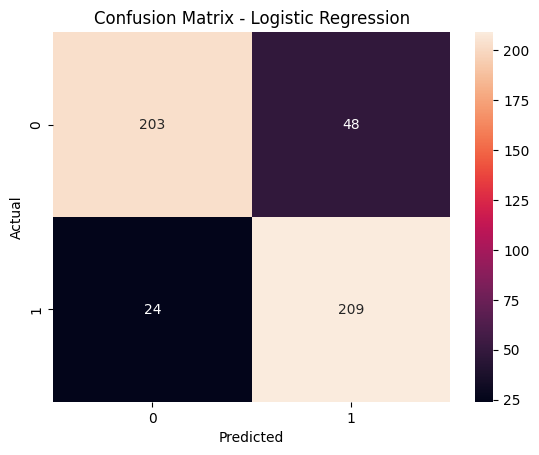

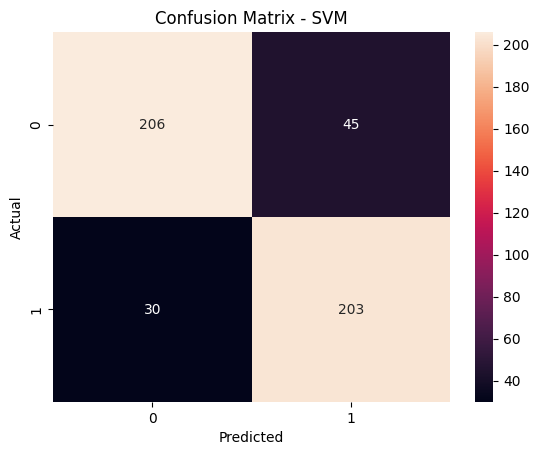

In [ ]:
models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred
}

for model_name, predictions in models.items():
    cm = confusion_matrix(y_test, predictions)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [ ]:
# -------- User Input Sentiment Prediction --------

user_text = input("Enter a review: ")

# Preprocess user input
clean_text = preprocess_text(user_text)

# Convert text to TF-IDF features
text_vector = tfidf.transform([clean_text])

# Predict sentiment using trained SVM model
prediction = svm_model.predict(text_vector)

if prediction[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")



Enter a review: good movie
Sentiment: Positive


In [ ]:
print("\nChoose Model for Sentiment Prediction")
print("1. Naive Bayes")
print("2. Logistic Regression")
print("3. SVM")

choice = int(input("Enter choice (1-3): "))
user_text = input("Enter a review: ")

clean_text = preprocess_text(user_text)
text_vector = tfidf.transform([clean_text])

if choice == 1:
    pred = nb_model.predict(text_vector)
    model_name = "Naive Bayes"
elif choice == 2:
    pred = lr_model.predict(text_vector)
    model_name = "Logistic Regression"
else:
    pred = svm_model.predict(text_vector)
    model_name = "SVM"

if pred[0] == 1:
    print(f"Model Used: {model_name}")
    print("Sentiment: Positive")
else:
    print(f"Model Used: {model_name}")
    print("Sentiment: Negative")



Choose Model for Sentiment Prediction
1. Naive Bayes
2. Logistic Regression
3. SVM
Enter choice (1-3): 1
Enter a review: it is good
Model Used: Naive Bayes
Sentiment: Positive
